# ДЗ1
### Задача: многоклассовая классификация
### Датасет: CIFAR-10
### Классы:
- plane
- car
- bird
- cat
- deer
- dog
- frog
- horse
- ship
- truck
### Архитектура: ResNet34

In [1]:
import torch
import wandb
from tqdm import tqdm
import torchvision as tv
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.cuda.amp import autocast
import torch.optim as optim
import torch.nn.functional as F
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms
from torchvision.utils import make_grid
from collections import defaultdict
from torch.utils.data.dataloader import DataLoader
from torch.utils.data import random_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score



import warnings
warnings.filterwarnings('ignore')

# Загружаем и нормализуем данные

In [2]:
transform = transforms.Compose([transforms.ToTensor(),
                                 transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 16
trainset = tv.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = tv.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat','deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Files already downloaded and verified
Files already downloaded and verified


Смотрим на примеры

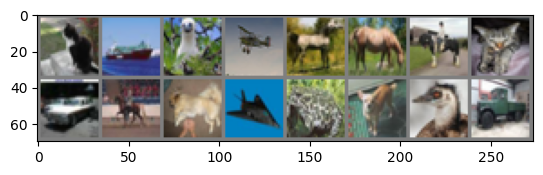

cat ship bird plane horse horse horse cat car horse dog plane frog dog bird truck


In [3]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(tv.utils.make_grid(images))
print(' '.join(f'{classes[labels[j]]}' for j in range(batch_size)))

# Метрики подсчета модели

In [4]:
def count_parameteres(model):
    """ Считаем парметры модели """
    count_parm = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Количество параметров модели: {count_parm}')


def accuracy(pred, label):
    answer = F.softmax(pred.detach()).numpy().argmax(1) == label.numpy() 
    return answer.mean()

def evaluate(model, dataloader, device, loss_fn, use_amp):
    model.eval()
    loss_val = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for img, label in dataloader:
            img, label = img.to(device), label.to(device)
            with torch.cuda.amp.autocast(enabled=use_amp):
                pred = model(img)
                loss = loss_fn(pred, label)
            
            loss_val += loss.item()
            all_preds.append(pred.argmax(dim=1).cpu().numpy())
            all_labels.append(label.cpu().numpy())

    avg_loss = loss_val / len(dataloader)
    
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    precision = precision_score(all_labels, all_preds, average='macro')
    recall = recall_score(all_labels, all_preds, average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')
    accuracy = (all_preds == all_labels).mean()
    return avg_loss, accuracy, precision, recall, f1

# Model

In [5]:
class ResBlock(nn.Module):
    def __init__(self, num_ch):
        super(ResBlock, self).__init__()
        self.conv1 = nn.Conv2d(num_ch, num_ch, kernel_size=3, padding=1)
        self.norm1 = nn.BatchNorm2d(num_ch)
        self.act = nn.LeakyReLU(0.2, inplace=True)
        self.conv2 = nn.Conv2d(num_ch, num_ch,kernel_size=3, padding=1)
        self.norm2 = nn.BatchNorm2d(num_ch)
    
    def forward(self, x):
        out = self.conv1(x)
        out = self.norm1(out)
        out = self.act(out)        
        out = self.conv2(out)
        out = self.norm2(out)

        return self.act(x + out)


class ResTruck(nn.Module):
    def __init__(self, num_ch, num_blocks):
        super(ResTruck, self).__init__()
        
        truck = []        
        for i in range(num_blocks):
            truck.append(ResBlock(num_ch))
        self.truck = nn.Sequential(*truck)
            
    def forward(self, x):
        return self.truck(x)


class ResNet(nn.Module):
    def __init__(self, in_ch, num_ch, out_ch):
        super(ResNet, self).__init__()
        
        self.conv0 = nn.Conv2d(in_ch, num_ch, kernel_size=7, stride=2, padding=3)
        self.norm = nn.BatchNorm2d(num_ch)
        self.act = nn.LeakyReLU(0.2, inplace=True)
        self.maxpool = nn.MaxPool2d(2,2, padding=1)

        self.layer1 = ResTruck(num_ch, 3) 
        self.conv1 = nn.Conv2d(num_ch, 2*num_ch, 3, padding=1, stride=2)
        
        self.layer2 = ResTruck(2*num_ch, 4) 
        self.conv2 = nn.Conv2d(2*num_ch, 4*num_ch, 3, padding=1, stride=2)
        
        self.layer3 = ResTruck(4*num_ch, 6) 
        self.conv3 = nn.Conv2d(4*num_ch, 8*num_ch, 3, padding=1, stride=2)
        
        self.layer4 = ResTruck(8*num_ch, 3) 
        
        self.avgpool = nn.AdaptiveAvgPool2d(output_size=(1,1))
        self.linear = nn.Linear(in_features=8*num_ch, out_features=out_ch)
    
    def forward(self, x):
        x = self.conv0(x)
        x = self.norm(x)
        x = self.act(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.conv1(x)
        x = self.layer2(x)
        x = self.conv2(x)
        x = self.layer3(x)
        x = self.conv3(x)
        x = self.layer4(x)
        x = self.avgpool(x)        
        x = self.linear(torch.flatten(x, 1))

        return x

In [6]:
model = ResNet(3, 64, 10)
count_parameteres(model)

Количество параметров модели: 24221066


# Обучаем модель

In [7]:
wandb.init(
    project="resnet34",
    config={
        "learning_rate": 0.001,
        "epochs": 7,
        "batch_size": trainloader.batch_size,
        "optimizer": "AdamW",
        "scheduler": "ExponentialLR",
        "model": "ResNet",
    },
)
wandb.watch(model, log="all", log_freq=10)


device = "cuda" if torch.cuda.is_available() else "cpu"
model = ResNet(3, 64, 10).to(device)
loss_fn = nn.CrossEntropyLoss().to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, betas=(0.8, 0.999))
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.6)

use_amp = True
scaler = torch.cuda.amp.GradScaler()
torch.backends.cudnn.benchmark = True

epochs = 7
train_loss = []
test_loss = []

acc_train_list = []
acc_test_list = []
precision_list = []
recall_list = []
f1_list = []

for epoch in range(epochs):
    model.train()
    loss_val = 0
    acc_val = 0
    for sample in tqdm(trainloader, desc=f"Epoch {epoch + 1}/{epochs}"):
        img, label = sample
        img, label = img.to(device), label.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=use_amp):
            pred = model(img)
            loss = loss_fn(pred, label)

        scaler.scale(loss).backward()
        loss_item = loss.item()
        loss_val += loss_item

        scaler.step(optimizer)
        scaler.update()

        acc_current = accuracy(pred.cpu().float(), label.cpu().float())
        acc_val += acc_current

    scheduler.step()

    train_loss_epoch = loss_val / len(trainloader)
    train_acc_epoch = acc_val / len(trainloader)
    train_loss.append(train_loss_epoch)
    acc_train_list.append(train_acc_epoch)

    test_loss_epoch, test_acc_epoch, precision_epoch, recall_epoch, f1_epoch = evaluate(
        model, testloader, device, loss_fn, use_amp
    )
    test_loss.append(test_loss_epoch)
    acc_test_list.append(test_acc_epoch)
    precision_list.append(precision_epoch)
    recall_list.append(recall_epoch)
    f1_list.append(f1_epoch)

    wandb.log({
        "train_loss": train_loss_epoch,
        "test_loss": test_loss_epoch,
        "train_accuracy": train_acc_epoch,
        "test_accuracy": test_acc_epoch,
        "precision": precision_epoch,
        "recall": recall_epoch,
        "f1_score": f1_epoch,        
    })

    print(f'Epoch: {epoch + 1}/{epochs}')
    print(f'Train Loss: {train_loss_epoch:.4f} | Train Accuracy: {train_acc_epoch:.4f}')
    print(f'Test Loss: {test_loss_epoch:.4f} | Test Accuracy: {test_acc_epoch:.4f}')
    print(f'Precision: {precision_epoch:.4f} | Recall: {recall_epoch:.4f} | F1-Score: {f1_epoch:.4f}')


wandb.finish()

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: ilike528149 (r1char9). Use `wandb login --relogin` to force relogin


Epoch 1/7: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3125/3125 [01:05<00:00, 47.56it/s]


Epoch: 1/7
Train Loss: 1.5738 | Train Accuracy: 0.4199
Test Loss: 1.2308 | Test Accuracy: 0.5579
Precision: 0.5597 | Recall: 0.5579 | F1-Score: 0.5471


Epoch 2/7: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3125/3125 [01:00<00:00, 51.73it/s]


Epoch: 2/7
Train Loss: 1.0818 | Train Accuracy: 0.6143
Test Loss: 1.0524 | Test Accuracy: 0.6328
Precision: 0.6460 | Recall: 0.6328 | F1-Score: 0.6314


...

Epoch 6/7: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3125/3125 [01:04<00:00, 48.08it/s]


Epoch: 6/7
Train Loss: 0.4138 | Train Accuracy: 0.8541
Test Loss: 0.7887 | Test Accuracy: 0.7478
Precision: 0.7481 | Recall: 0.7478 | F1-Score: 0.7468


Epoch 7/7: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3125/3125 [01:08<00:00, 45.66it/s]


Epoch: 7/7
Train Loss: 0.3328 | Train Accuracy: 0.8846
Test Loss: 0.8134 | Test Accuracy: 0.7500
Precision: 0.7505 | Recall: 0.7500 | F1-Score: 0.7497


f1_score,▁▄▆▇███
precision,▁▄▆▇███
recall,▁▄▆▇███
test_accuracy,▁▄▆▇███
test_loss,█▅▂▂▁▁▂
train_accuracy,▁▄▅▆▇██
train_loss,█▅▄▃▂▁▁
f1_score,0.7497
precision,0.75046
recall,0.75
test_accuracy,0.75


In [8]:
correct_per_class = defaultdict(int)  
total_per_class = defaultdict(int)    

model.eval()
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        for label, pred in zip(labels, predicted):
            total_per_class[label.item()] += 1
            if label.item() == pred.item():
                correct_per_class[label.item()] += 1

per_class_accuracy = {}
for cls_idx in range(len(classes)):
    accuracy = correct_per_class[cls_idx] / total_per_class[cls_idx] if total_per_class[cls_idx] > 0 else 0
    per_class_accuracy[classes[cls_idx]] = accuracy

for cls_name, acc in per_class_accuracy.items():
    print(f"{cls_name}: {acc * 100:.2f}%")

plane: 78.20%
car: 84.90%
bird: 63.70%
cat: 60.10%
deer: 70.10%
dog: 60.80%
frog: 82.40%
horse: 79.80%
ship: 88.00%
truck: 82.20%
